### **Libraries and Datasets**

Way to download required packages using `pip`:

In [ ]:
# %pip install -U numpy
# %pip install -U pandas
# %pip install catboost
# %pip install -U scikit-learn
# %pip install optuna
# %pip install matplotlib seaborn

Import of necessary libraries:

In [55]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import ast

import warnings
warnings.filterwarnings('ignore')

Datasets uploading:

In [38]:
train_data = pd.read_csv('train_contest.csv')
train_data.head()

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0


In [39]:
test_data = pd.read_csv('for_prediction.csv')
test_data.head()

,Id,premium,name,department,has_test,response_letter_required,area,type,address,response_url,...,working_days,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url
0,0,False,Помощник маркетолога,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","[{'id': '3.206', 'name': 'Печатная реклама', '...",Москва,NaN
1,1,False,Менеджер по персоналу,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Новочер...",NaN,...,[],[],[],False,<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Санкт-Петербург,NaN
2,2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",NaN,False,False,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Уфа', 'street': 'Рубежная улица', 'b...",NaN,...,[],[],[],False,"<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'noExperience', 'name': 'Нет опыта'}",[],"[{'id': '24.378', 'name': 'Тренерский состав',...",Республика Башкортостан,NaN
3,3,False,Программист Delphi,NaN,False,False,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>Компания AMS Software - разработчик популяр...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","[{'id': '1.221', 'name': 'Программирование, Ра...",Новосибирская область,NaN
4,4,False,Ведущий специалист ВКС,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Чистопрудный бул...",NaN,...,[],[],[],False,<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","[{'id': '1.172', 'name': 'Начальный уровень, М...",Москва,NaN


Some preparations of datasets before feature engineering such as choosing start features (features without NaNs or empty arrays as values):

In [40]:
features = ['name', 'region', 'address', 'employer', 'description', 'schedule', 'key_skills', 'experience', 'specializations']
X_train = train_data[features]  # start features
y_train = train_data['mean_salary']  # target variable

In [41]:
X_train.head()

,name,region,address,employer,description,schedule,key_skills,experience,specializations
0,Агент по недвижимости,Санкт-Петербург,"{'city': 'Санкт-Петербург', 'street': 'Невский...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '20.20', 'name': 'Агент', 'profarea_id..."
1,IT-специалист/ техник,Иркутская область,NaN,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...",<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."
2,Старший/ведущий инженер-программист,Ростовская область,"{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.221', 'name': 'Программирование, Ра..."
3,Эксперт / методист приемной комиссии,Москва,"{'city': 'Москва', 'street': '1-я Миусская ули...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...",<p>Департамент информационных технологий РХТУ ...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.150', 'name': 'Менеджмент продукта ..."
4,Табельщица/табельщик,Саратовская область,"{'city': None, 'street': None, 'building': Non...","{'id': '617150', 'name': 'Сигнал, группа компа...",<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '18.142', 'name': 'Машиностроение', 'p..."


In [42]:
X_test = test_data[features]
X_test.head()

,name,region,address,employer,description,schedule,key_skills,experience,specializations
0,Помощник маркетолога,Москва,NaN,"{'id': '2710310', 'name': 'EKO BIKE', 'url': '...",<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.206', 'name': 'Печатная реклама', '..."
1,Менеджер по персоналу,Санкт-Петербург,"{'city': 'Санкт-Петербург', 'street': 'Новочер...","{'id': '52824', 'name': 'Ваш дом, агентство не...",<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '6.254', 'name': 'Рекрутмент', 'profar..."
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'city': 'Уфа', 'street': 'Рубежная улица', 'b...","{'id': '230048', 'name': 'Мегаполис', 'url': '...","<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'fullDay', 'name': 'Полный день'}",[],"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '24.378', 'name': 'Тренерский состав',..."
3,Программист Delphi,Новосибирская область,NaN,"{'id': '634253', 'name': 'AMS Software', 'url'...",<p>Компания AMS Software - разработчик популяр...,"{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'id': '1.221', 'name': 'Программирование, Ра..."
4,Ведущий специалист ВКС,Москва,"{'city': 'Москва', 'street': 'Чистопрудный бул...","{'id': '36889', 'name': 'Технокад', 'url': 'ht...",<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."


### **Target Variable Processing**

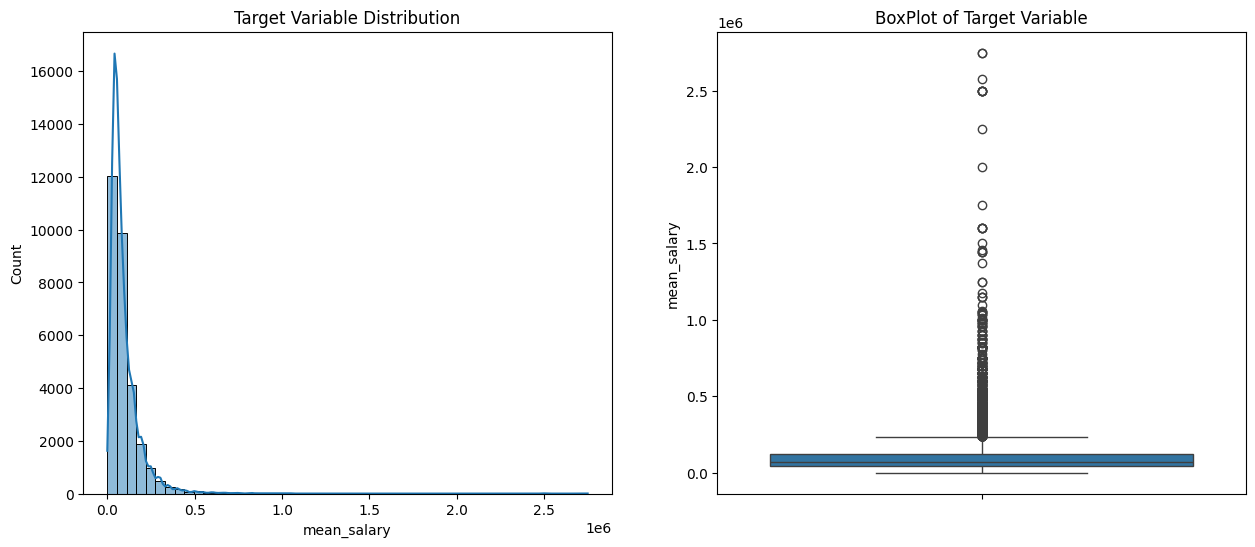

In [46]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.boxplot(y_train)
plt.title('BoxPlot of Target Variable')

plt.show()

In [47]:
y_train = y_train.to_frame()

In [49]:
y_train['mean_salary_transformed'] = np.log1p(y_train['mean_salary'])
scaler = RobustScaler(
    quantile_range=(15, 85),
    with_scaling=False,
    unit_variance=True
)
y_train['mean_salary_transformed'] = scaler.fit_transform(y_train[['mean_salary_transformed']])

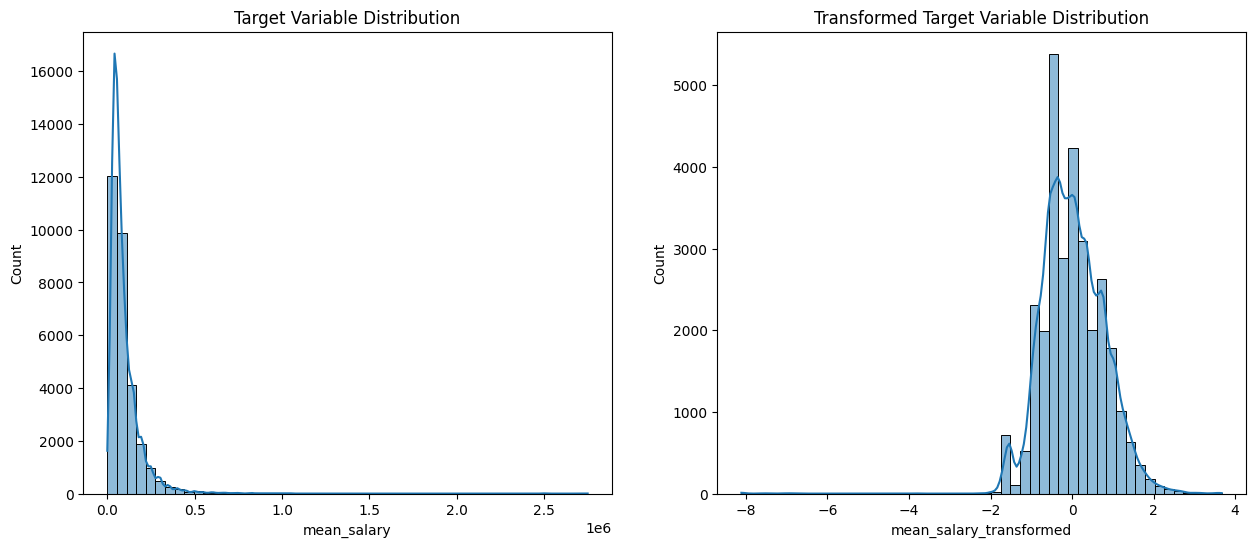

In [50]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.histplot(y_train['mean_salary_transformed'], bins=50, kde=True)
plt.title('Transformed Target Variable Distribution')

plt.show()

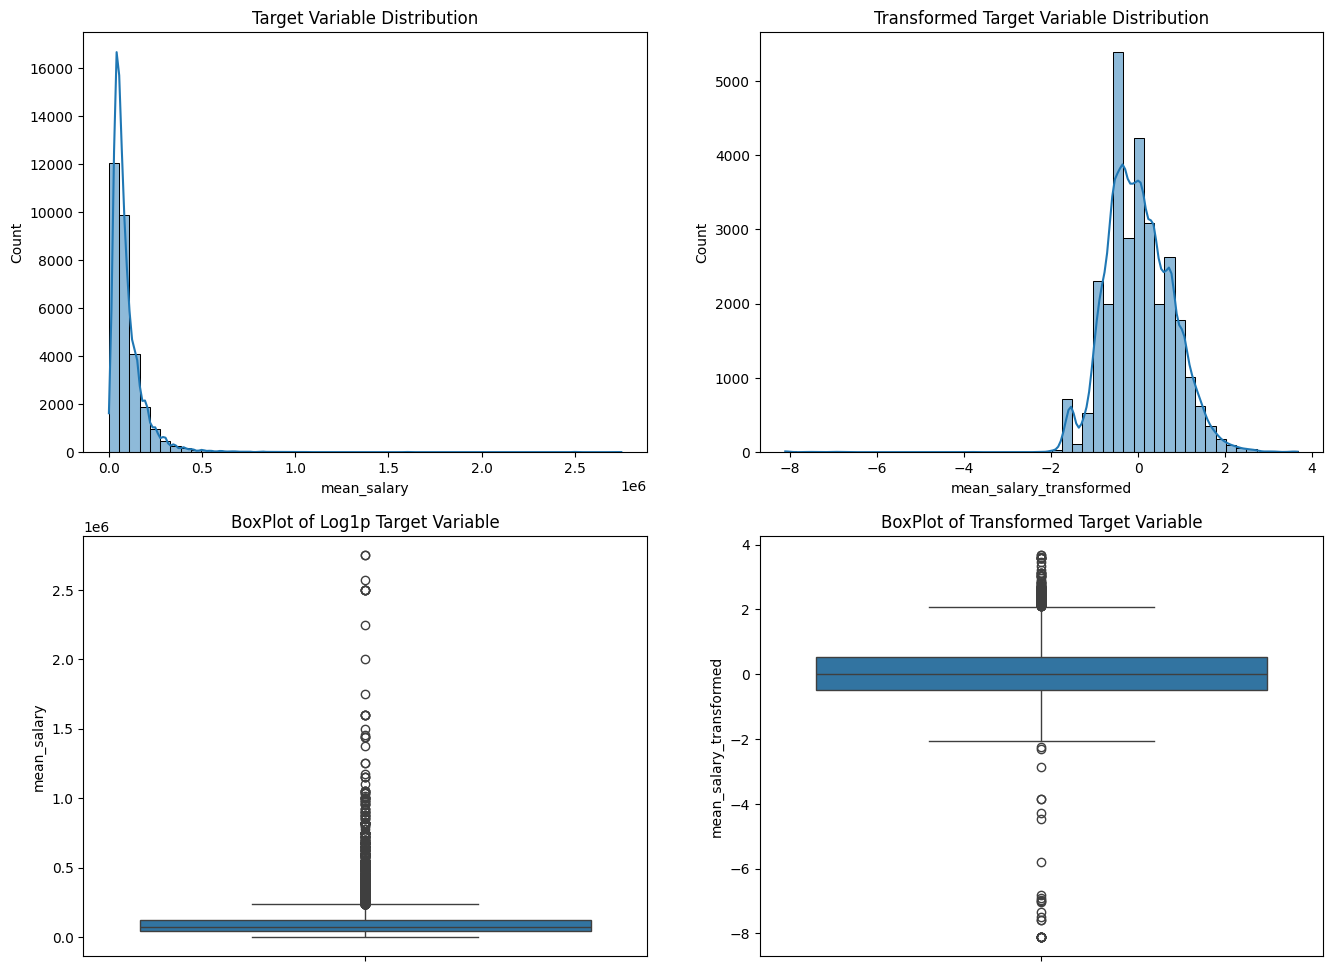

In [51]:
plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 2, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(2, 2, 2)
sns.histplot(y_train['mean_salary_transformed'], bins=50, kde=True)
plt.title('Transformed Target Variable Distribution')

ax2 = plt.subplot(2, 2, 3)
sns.boxplot(y_train['mean_salary'])
plt.title('BoxPlot of Log1p Target Variable')

ax5 = plt.subplot(2, 2, 4)
sns.boxplot(y_train['mean_salary_transformed'])
plt.title('BoxPlot of Transformed Target Variable')

plt.show()

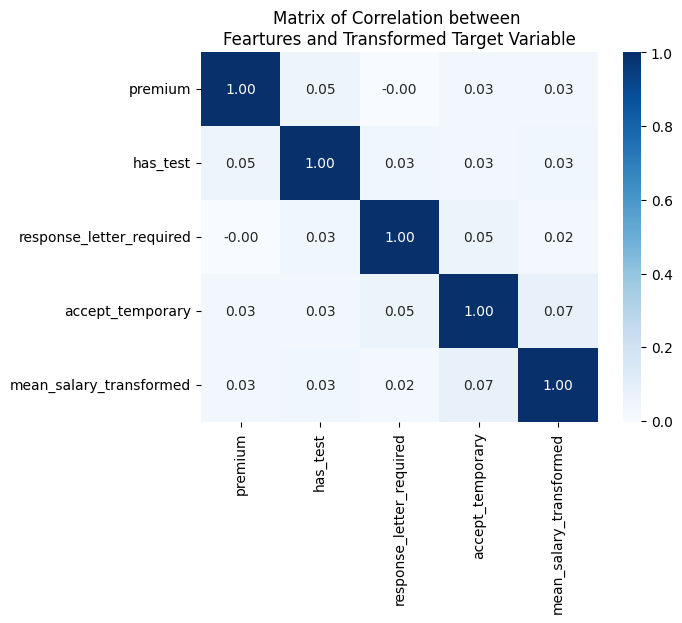

In [54]:
features_corr = pd.concat([train_data[['premium', 'has_test', 'response_letter_required', 'accept_temporary']], y_train['mean_salary_transformed']], axis=1)
correlation = features_corr.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nFeartures and Transformed Target Variable')
plt.show()

### **Feature Engineering**

Some ideas and functional realization of feature engineering:

In [56]:
def str_to_dict(s):
    return ast.literal_eval(s)

In [57]:
len_train, len_test = X_train.shape[0], X_test.shape[0]
print(f'Num of rows in train: {len_train} \nNum of rows in test: {len_test}')

Num of rows in train: 30072 
Num of rows in test: 7518


Some experiments showed that it's quite useful, so, new column with *description length*:

In [59]:
for df in [X_train, X_test]:
    df['description_len'] = df['description'].apply(lambda x: len(x) if isinstance(x, str) else 0)
    df.drop(['description'], axis=1, inplace=True)

Also, new column with *ages of experience* got from experience column in dict format:

In [58]:
for df in [X_train, X_test]:
    df['experience_ages'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['experience_ages'][i] = str_to_dict(df['experience'][i])['id']

It is decided to use `OrdinalEncoder` for better interpretation of the *experience* feature:

In [60]:
exp_categories = ['noExperience', 'between1And3', 'between3And6', 'moreThan6']
ord_encoder = OrdinalEncoder(categories=[exp_categories])
for df in [X_train, X_test]:
    df['experience_encoded'] = ord_encoder.fit_transform(df[['experience_ages']])
    df.drop(['experience', 'experience_ages'], axis=1, inplace=True)

The feature *specializations* is modified to the dictionary which format is *'professional area': 'role in the area'*. It contains the sets of roles for the set of professional areas for each row:

In [61]:
for df in [X_train, X_test]:
    n = df.shape[0]
    for i in range(n):
        df['specializations'][i] = str_to_dict(df['specializations'][i])
    df['specs'] = [None for _ in range(n)]
    for j in range(n):
        keys = set([df['specializations'][j][i]['profarea_name'] for i in range(len(df['specializations'][j]))])
        specs_dict = {}
        for k in keys:
            specs_dict[k] = set()
        for i in range(len(df['specializations'][j])):
            specs_dict[df['specializations'][j][i]['profarea_name']].add(df['specializations'][j][i]['name'])

        df['specs'][j] = specs_dict
    
    df.drop(['specializations'], axis=1, inplace=True)
    for i in range(n):
        df['specs'][i] = str(df['specs'][i])

New column made with *number of specializations* for each vacansy response:

In [66]:
for df in [X_train, X_test]:
    df['num_specs'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['specs'][i] = str_to_dict(df['specs'][i])
        number = 0
        for _, v in df['specs'][i].items():
            number += len(v)
        df['num_specs'][i] = number
        df['specs'][i] = str(df['specs'][i])
    df.drop(['num_specs'], axis=1, inplace=True)

One more new idea for feature extraction was to make a formula $$\operatorname{rating} = \alpha * \operatorname{grade} + \displaystyle \frac{\beta * \operatorname{knowledge}}{4-\operatorname{grade}},$$

where `rating` is some rating feature which will be used for ranking making, `grade` is a qualification level, `knowledge` is a feature which is the concrete ranking was made for.

Let them be $\alpha = 5, \ \beta = 4$ for *specializations ranking* and $\alpha = 4.5, \ \beta = 2$ for *key skills ranking* and make new features:

In [64]:
def rating(grade, knowledge, alpha, beta):
    return alpha * grade + beta * knowledge / (4 - grade)

for df in [X_train, X_test]:
    df['spec_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['spec_rating'][i] = rating(
            grade=df['experience_encoded'][i],
            knowledge=df['num_specs'][i],
            alpha=5,
            beta=4
        )

In [65]:
for df in [X_train, X_test]:
    df['key_skills_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['key_skills_rating'][i] = rating(
            grade=df['experience_encoded'][i],
            knowledge=len(str_to_dict(df['key_skills'][i])),
            alpha=4.5,
            beta=2
        )

Check for features updates:

In [67]:
X_train.head()

,name,region,address,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Агент по недвижимости,Санкт-Петербург,"{'city': 'Санкт-Петербург', 'street': 'Невский...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",1792,0.0,"{'Строительство, недвижимость': {'Жилье', 'Нач...",5.0,3.0
1,IT-специалист/ техник,Иркутская область,NaN,"{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],2492,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,4.5
2,Старший/ведущий инженер-программист,Ростовская область,"{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",762,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,6.5
3,Эксперт / методист приемной комиссии,Москва,"{'city': 'Москва', 'street': '1-я Миусская ули...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1709,1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук...",7.666667,7.833333
4,Табельщица/табельщик,Саратовская область,"{'city': None, 'street': None, 'building': Non...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",533,1.0,"{'Производство, сельское хозяйство': {'Машинос...",6.333333,9.166667


In [68]:
X_test.head()

,name,region,address,employer,schedule,key_skills,description_len,experience_encoded,specs,spec_rating,key_skills_rating
0,Помощник маркетолога,Москва,NaN,"{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...",894,1.0,"{'Маркетинг, реклама, PR': {'Наружная реклама'...",11.666667,7.833333
1,Менеджер по персоналу,Санкт-Петербург,"{'city': 'Санкт-Петербург', 'street': 'Новочер...","{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...",1337,0.0,"{'Управление персоналом, тренинги': {'Рекрутме...",4.0,3.0
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'city': 'Уфа', 'street': 'Рубежная улица', 'b...","{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],952,0.0,"{'Спортивные клубы, фитнес, салоны красоты': {...",1.0,0.0
3,Программист Delphi,Новосибирская область,NaN,"{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...",2248,2.0,"{'Информационные технологии, интернет, телеком...",20.0,14.0
4,Ведущий специалист ВКС,Москва,"{'city': 'Москва', 'street': 'Чистопрудный бул...","{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...",977,1.0,"{'Информационные технологии, интернет, телеком...",11.666667,8.5


Let's check correlations between transformed target and extracted features for being sure whether they will be better than previous ones for fitting the model or not:

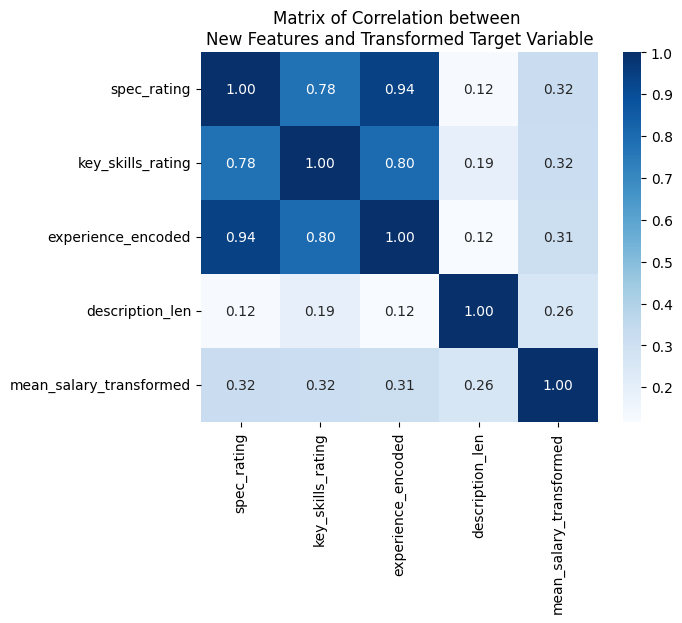

In [69]:
corr_test_df = pd.concat([X_train[['spec_rating', 'key_skills_rating', 'experience_encoded', 'description_len']], y_train['mean_salary_transformed']], axis=1)
correlation = corr_test_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nNew Features and Transformed Target Variable')
plt.show()

We realized that we extracted quite good features for training, because the correlation increased 5 times or more :)

By the way, let's make one more categorial feature and add transformed *address* feature:

In [70]:
for df in [X_train, X_test]:
    for i in range(df.shape[0]):
        if pd.isna(df.loc[i, 'address']):
            df['address'][i] = str(
                {'city': df['region'][i],
                 'street': None,
                 'building': None,
                 'description': None,
                 'lat': None,
                 'lng': None,
                 'raw': None,
                 'metro': None,
                 'metro_stations': [],
                 'id': None}
                )

### **Model Initialization and Optimization**

#### CatBoost

For fitting and predicting the `CatBoostRegressor` model (from `catboost` library) is selected. It's a good regression model, especially in categorial features processing. Build-in methods of encoding-decoding and feature transformations actually are able to work better than other methods of feature preprocessing such as scalers or encoders from Scikit-learn or other libraries.

`Optuna` Framework usage for optimal selection of CatBoost Regressor hyperparameters:

In [ ]:
cat_features = ['name', 'region', 'address', 'employer', 'schedule', 'key_skills', 'specs']

def objective(trial):
    global cat_features
    params = {
        'depth': trial.suggest_int('depth', 12, 14),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.03, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 8, 9),
        'iterations': trial.suggest_int('iterations', 1400, 1600),
        'random_strength': trial.suggest_float('random_strength', 1, 1.5),
    }
    
    model = CatBoostRegressor(**params, loss_function='MAE', cat_features=cat_features, verbose=50)
    score = cross_val_score(model, X_train, y_train['mean_salary_transformed'], cv=4, scoring="neg_mean_absolute_error")
    
    return -score.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

In [ ]:
print(f'Best hyperparameters: {study.best_params}')

`Optuna` was used for trying to find the best hyperparameters and rounded the result after all. So, `CatBoostRegressor` model was realized like this:

In [71]:
cat_features = ['name', 'region', 'address', 'employer', 'schedule', 'key_skills', 'specs']
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.04,
    depth=12,
    l2_leaf_reg=8.7,
    loss_function='MAE',
    od_type='Iter',
    od_wait=30,
    leaf_estimation_iterations=10,
    random_strength=1.3,
    min_data_in_leaf=10
)

Process of CatBoost model fitting:

In [72]:
model.fit(X_train, y_train['mean_salary_transformed'], cat_features=cat_features, verbose=50)

0:	learn: 0.5852607	total: 90.4ms	remaining: 2m 15s
50:	learn: 0.3292667	total: 1.7s	remaining: 48.4s
100:	learn: 0.2925151	total: 3.69s	remaining: 51.1s
150:	learn: 0.2738548	total: 5.96s	remaining: 53.3s
200:	learn: 0.2610169	total: 8.23s	remaining: 53.2s
250:	learn: 0.2516837	total: 10.6s	remaining: 52.7s
300:	learn: 0.2423246	total: 13s	remaining: 51.9s
350:	learn: 0.2323710	total: 15.4s	remaining: 50.6s
400:	learn: 0.2240953	total: 17.9s	remaining: 49s
450:	learn: 0.2160359	total: 20.4s	remaining: 47.3s
500:	learn: 0.2087381	total: 22.8s	remaining: 45.5s
550:	learn: 0.2028759	total: 25.3s	remaining: 43.5s
600:	learn: 0.1972372	total: 27.7s	remaining: 41.4s
650:	learn: 0.1921791	total: 30.1s	remaining: 39.2s
700:	learn: 0.1880912	total: 32.5s	remaining: 37.1s
750:	learn: 0.1842140	total: 35s	remaining: 34.9s
800:	learn: 0.1805739	total: 37.4s	remaining: 32.6s
850:	learn: 0.1767318	total: 39.8s	remaining: 30.3s
900:	learn: 0.1734019	total: 42.2s	remaining: 28s
950:	learn: 0.1703194	

It's also worth checking features importance after fitting (how much they influenced on model fitting):

            Feature Id  Importances
0                specs    15.786293
1               region    15.192168
2             employer    12.034158
3      description_len    11.338730
4             schedule    10.535790
5                 name     9.820658
6              address     6.392061
7    key_skills_rating     6.030846
8          spec_rating     5.839261
9   experience_encoded     4.096438
10          key_skills     2.933598


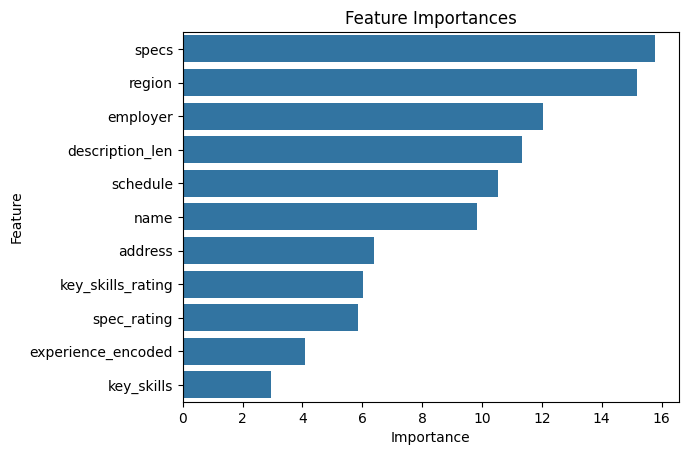

In [73]:
feature_importances = model.get_feature_importance(prettified=True)

print(feature_importances)

sns.barplot(x='Importances', y='Feature Id', data=feature_importances)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### **Submission Data Prediction and Exporting**

Predict mean salary of vacancies at the test dataset (in the transformed form) and then apply the inverse transformation (`numpy.expm1()` and `RobustScaler().inverse_transform()`):

In [76]:
y_hat_tr = model.predict(X_test)
y_hat_log = scaler.inverse_transform(y_hat_tr.reshape(-1, 1)).flatten()
y_hat = np.expm1(y_hat_log)

`y_hat` is the result data which is ready for exporting and MAE metric counting: $$\operatorname{MAE} = \displaystyle \frac{1}{n} \sum_{i=1}^{n}|\hat{y_i} - y_i|.$$

Turn the result data to `pandas.DataFrame()` and export them:

In [77]:
submission_data = pd.DataFrame({'Id': range(len(y_hat)), 'Predicted': y_hat})
submission_data

,Id,Predicted
0,0,34877.294421
1,1,42335.161869
2,2,25790.002924
3,3,172223.374076
4,4,65673.698199
...,...,...
7513,7513,36253.126485
7514,7514,79462.787389
7515,7515,26365.113606
7516,7516,105056.956367


In [78]:
submission_data.to_csv('submission.csv', index=False, encoding='utf-8')

### **Results**

We realized that the final score of MAE metric was $$\operatorname{MAE} = 29632.48077,$$ which is the **3rd-place** result.